# Chứng minh mapping `category` (1010–1050): README vs UI Nhà Tốt vs Raw Data

Notebook này **chứng minh bằng số liệu thực** (không chỉ lý thuyết) các luận điểm:

1. Data Dictionary trong **README đề bài lệch** so với 5 loại BĐS trên UI đăng tin.
2. Mapping đúng: **1010=Căn hộ**, **1020=Nhà ở**, **1030=Mặt bằng/Văn phòng**, **1040=Đất**, **1050=Phòng trọ**.
3. **1050** không phải "Dự án mới": ~100% `let`, 0% `project_id`, CVR **sell ≈ 0**.
4. Field cấu trúc (`house_type`, `floors`, `bedrooms`…) khớp form UI từng loại.
5. Rule NLP trên `title` + ma trận nhầm lẫn; lệch `ad_type` vs title.
6. DQ địa chỉ (`city` / `district` / `ward`).

**Chạy:** kernel Python có `requirements-eda.txt`. Mở notebook từ thư mục gốc `Datathon_Data`.

**Biểu đồ:** hiển thị **inline** trong output cell (không popup). Cell đầu bật `%matplotlib inline`.

Kết quả export: `outputs/category_mapping/`

File đọc số liệu (không nhận định): **`outputs/category_mapping/category_mapping_data_summary.md`**

**§10b** — bảng 5 dòng: la_gi_dung + readme_sai + chứng minh hành vi/title/form + title_mau + ket_luan.

Sau khi chạy §12: thêm `12a`–`12g` (diện tích, phòng ngủ, pháp lý, snapshot, post_contact).

**§13:** quy tắc EDA theo `category` + luồng thuộc tính `dim_listing` → `13*.csv`.

In [33]:
%matplotlib inline

In [34]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import duckdb
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

plt.ioff()  # không mở cửa sổ popup — chỉ render trong notebook
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})


def show_and_save(name: str, dpi: int = 150) -> None:
    """Lưu PNG + hiển thị chart ngay dưới cell (inline)."""
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    display(plt.gcf())
    plt.close()
    print(f"Saved → {path}")


def field_fill_rate(series: pd.Series) -> float:
    """% có giá trị thực (numeric > 0 hoặc chuỗi không rỗng)."""
    if pd.api.types.is_numeric_dtype(series):
        mask = series.notna() & np.isfinite(series) & (series > 0)
    else:
        mask = series.notna() & series.astype(str).str.strip().ne("")
    return 100 * mask.mean() if len(series) else 0.0


DATA_ROOT = Path.cwd().resolve()
for name in ("dim_listing", "fact_user_events"):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(f"Thiếu `{name}` trong {DATA_ROOT}")

OUT_DIR = DATA_ROOT / "outputs" / "category_mapping"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")

POSITIVE_TYPES = (
    "view_phone", "contact_chat", "other_interaction",
    "contact_zalo", "contact_sms",
)
POS_SQL = ", ".join(repr(x) for x in POSITIVE_TYPES)

con = duckdb.connect()
con.execute("SET memory_limit='2GB'")
con.execute("SET threads TO 2")

CAT_ORDER = [1010, 1020, 1030, 1040, 1050]

# README (đề bài) — giả thuyết cần bác bỏ / đối chiếu
README_LABELS = {
    1010: "Phòng trọ / căn hộ cho thuê",
    1020: "Căn hộ / chung cư",
    1030: "Nhà ở",
    1040: "Đất nền / BĐS thương mại",
    1050: "Dự án / căn hộ mở bán mới",
}

# UI Nhà Tốt + bằng chứng data (mapping đúng)
UI_LABELS = {
    1010: "Căn hộ / Chung cư",
    1020: "Nhà ở",
    1030: "Văn phòng / Mặt bằng kinh doanh",
    1040: "Đất",
    1050: "Phòng trọ",
}

UI_SLUG = {
    1010: "can_ho",
    1020: "nha_o",
    1030: "mat_bang",
    1040: "dat",
    1050: "phong_tro",
}

PALETTE = {1010: "#2171b5", 1020: "#cb181d", 1030: "#6a51a3", 1040: "#e6550d", 1050: "#238b45"}

print(f"DATA_ROOT = {DATA_ROOT}")
print(f"OUT_DIR   = {OUT_DIR}")

DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
OUT_DIR   = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping


## §1 — Bảng đối chiếu README vs UI (giả thuyết cần chứng minh)

In [35]:
mapping_df = pd.DataFrame({
    "category": CAT_ORDER,
    "readme_label": [README_LABELS[c] for c in CAT_ORDER],
    "ui_label_corrected": [UI_LABELS[c] for c in CAT_ORDER],
    "nlp_slug": [UI_SLUG[c] for c in CAT_ORDER],
    "readme_matches_ui": [
        README_LABELS[c].split("/")[0].strip()[:4].lower()
        in UI_LABELS[c].lower()
        for c in CAT_ORDER
    ],
})
mapping_df["readme_matches_ui"] = mapping_df.apply(
    lambda r: r["readme_label"].split("/")[0].strip().lower()
    in r["ui_label_corrected"].lower()
    or r["ui_label_corrected"].lower() in r["readme_label"].lower(),
    axis=1,
)
# Đánh dấu rõ: chỉ 1040 là gần đúng
mapping_df["verdict"] = mapping_df["readme_matches_ui"].map(
    {True: "Gần khớp", False: "LỆCH — dùng ui_label_corrected"}
)
display(mapping_df)
mapping_df.to_csv(OUT_DIR / "01_readme_vs_ui_mapping.csv", index=False)
Markdown("**Kỳ vọng:** hầu hết dòng `verdict` = *LỆCH* (chỉ 1040 gần đúng).")

,category,readme_label,ui_label_corrected,nlp_slug,readme_matches_ui,verdict
0,1010,Phòng trọ / căn hộ cho thuê,Căn hộ / Chung cư,can_ho,False,LỆCH — dùng ui_label_corrected
1,1020,Căn hộ / chung cư,Nhà ở,nha_o,False,LỆCH — dùng ui_label_corrected
2,1030,Nhà ở,Văn phòng / Mặt bằng kinh doanh,mat_bang,False,LỆCH — dùng ui_label_corrected
3,1040,Đất nền / BĐS thương mại,Đất,dat,True,Gần khớp
4,1050,Dự án / căn hộ mở bán mới,Phòng trọ,phong_tro,False,LỆCH — dùng ui_label_corrected


**Kỳ vọng:** hầu hết dòng `verdict` = *LỆCH* (chỉ 1040 gần đúng).

## §2 — Load `dim_listing` & thống kê nền

In [36]:
DIM_COLS = [
    "item_id", "category", "title", "ad_type", "price_bucket",
    "area_sqm", "bedrooms", "bathrooms", "floors", "width_m",
    "house_type", "project_id", "city_name", "district_name", "ward_name",
    "seller_type",
]

dim = con.execute(f"""
    SELECT {', '.join(DIM_COLS)}
    FROM read_parquet('{DIM_GLOB}')
""").df()

dim["category"] = dim["category"].astype(int)
dim["readme_label"] = dim["category"].map(README_LABELS)
dim["ui_label"] = dim["category"].map(UI_LABELS)
dim["category_ui_slug"] = dim["category"].map(UI_SLUG)

dim["is_monthly_price"] = dim["price_bucket"].astype(str).str.contains(
    r"/tháng|M/tháng|triệu/tháng", regex=True, na=False
)
dim["has_project_id"] = dim["project_id"].notna() & (dim["project_id"].astype(str).str.len() > 0)
dim["loc_complete"] = (
    dim["city_name"].notna()
    & dim["district_name"].notna()
    & dim["ward_name"].notna()
)

print(f"Tổng tin dim_listing: {len(dim):,}")
display(dim.groupby("category", as_index=False).agg(
    n=("item_id", "count"),
    ui_label=("ui_label", "first"),
    readme_label=("readme_label", "first"),
))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Tổng tin dim_listing: 3,107,114


,category,n,ui_label,readme_label
0,1010,611823,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê
1,1020,1507864,Nhà ở,Căn hộ / chung cư
2,1030,252402,Văn phòng / Mặt bằng kinh doanh,Nhà ở
3,1040,373469,Đất,Đất nền / BĐS thương mại
4,1050,361556,Phòng trọ,Dự án / căn hộ mở bán mới


## §3 — Chứng minh A: `ad_type` & `price_bucket` theo category

UI có **Bán / Cho thuê**. Nếu 1050 là "dự án mở bán" thì phải có tỉ lệ `sell` đáng kể và giá theo tỷ — không phải 100% giá/tháng.

,category,ui_label,ad_type,n,pct_in_category
0,1010,Căn hộ / Chung cư,let,454716,74.32
1,1010,Căn hộ / Chung cư,sell,157107,25.68
2,1020,Nhà ở,let,426019,28.25
3,1020,Nhà ở,sell,1081845,71.75
4,1030,Văn phòng / Mặt bằng kinh doanh,let,236484,93.69
5,1030,Văn phòng / Mặt bằng kinh doanh,sell,15918,6.31
6,1040,Đất,let,7957,2.13
7,1040,Đất,sell,365512,97.87
8,1050,Phòng trọ,let,361553,100.00
9,1050,Phòng trọ,sell,3,0.00


,category,n,pct_monthly,ui_label
0,1010,611823,74.321495,Căn hộ / Chung cư
1,1020,1507864,28.253145,Nhà ở
2,1030,252402,93.693394,Văn phòng / Mặt bằng kinh doanh
3,1040,373469,2.130565,Đất
4,1050,361556,99.999170,Phòng trọ


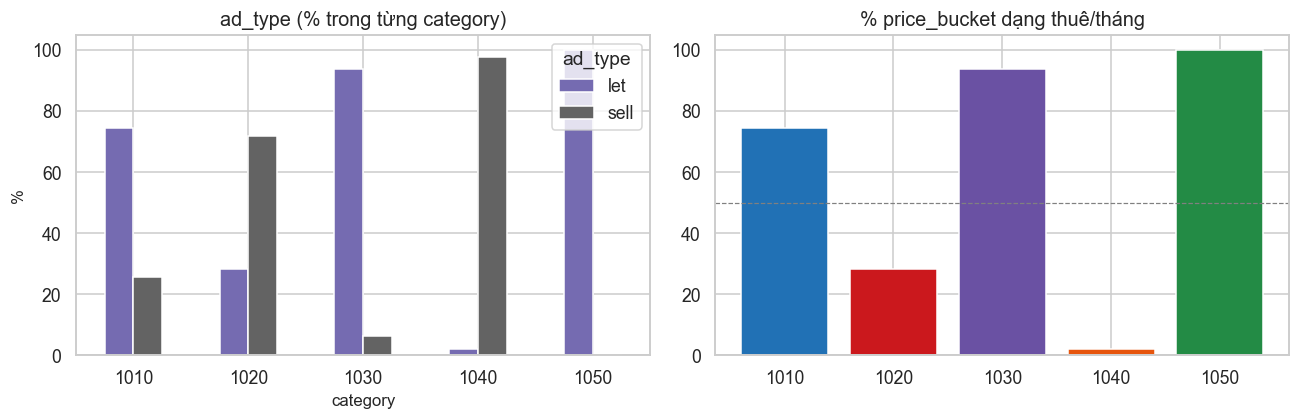

Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/fig_adtype_monthly.png
✓ Assertions §3 passed (1050=let+monthly, 1040=sell-heavy)


In [37]:
adtype = (
    dim.groupby(["category", "ui_label", "ad_type"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
)
adtype["pct_in_category"] = (
    100 * adtype["n"] / adtype.groupby("category")["n"].transform("sum")
).round(2)
display(adtype.sort_values(["category", "ad_type"]))
adtype.to_csv(OUT_DIR / "02_ad_type_by_category.csv", index=False)

monthly = dim.groupby("category").agg(
    n=("item_id", "count"),
    pct_monthly=("is_monthly_price", lambda s: 100 * s.mean()),
    ui_label=("ui_label", "first"),
).reset_index()
display(monthly)
monthly.to_csv(OUT_DIR / "03_monthly_price_share.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ct = pd.crosstab(dim["category"], dim["ad_type"], normalize="index") * 100
ct = ct.reindex(CAT_ORDER)
ct.plot(kind="bar", ax=axes[0], color=["#756bb1", "#636363"], rot=0)
axes[0].set_title("ad_type (% trong từng category)")
axes[0].set_xlabel("category")
axes[0].set_ylabel("%")
axes[0].legend(title="ad_type")

axes[1].bar(
    [str(c) for c in monthly["category"]],
    monthly["pct_monthly"],
    color=[PALETTE[c] for c in monthly["category"]],
)
axes[1].set_title("% price_bucket dạng thuê/tháng")
axes[1].set_ylim(0, 105)
axes[1].axhline(50, color="gray", ls="--", lw=0.8)
show_and_save("fig_adtype_monthly.png")

assert dim.loc[dim.category == 1050, "ad_type"].eq("let").mean() > 0.999, "1050 phải ~100% let"
assert dim.loc[dim.category == 1050, "is_monthly_price"].mean() > 0.999, "1050 phải ~100% giá/tháng"
assert dim.loc[dim.category == 1040, "ad_type"].eq("sell").mean() > 0.95, "1040 phải ~98% sell"
print("✓ Assertions §3 passed (1050=let+monthly, 1040=sell-heavy)")

## §4 — Chứng minh B: Độ điền field cấu trúc (khớp form UI)

| UI | Field kỳ vọng trong data |
|----|---------------------------|
| Phòng trọ (1050) | Chỉ area, furnishing — **không** bedrooms/floors/project |
| Căn hộ (1010) | bedrooms, project_id — **không** floors |
| Nhà ở (1020) | floors, width_m, **house_type** |
| Đất (1040) | width_m, **không** bedrooms |
| Mặt bằng (1030) | Tối giản — **không** bedrooms |

,category,ui_label,n,pct_bedrooms,pct_bathrooms,pct_floors,pct_width_m,pct_house_type,pct_has_project_id
0,1010,Căn hộ / Chung cư,611823,100.0,95.30,0.00,0.00,0.0,41.40
1,1020,Nhà ở,1507864,100.0,74.98,60.74,76.28,100.0,3.27
2,1030,Văn phòng / Mặt bằng kinh doanh,252402,0.0,0.00,0.00,0.00,0.0,6.46
3,1040,Đất,373469,0.0,0.00,0.00,82.47,0.0,8.56
4,1050,Phòng trọ,361556,0.0,0.00,0.00,0.00,0.0,0.00


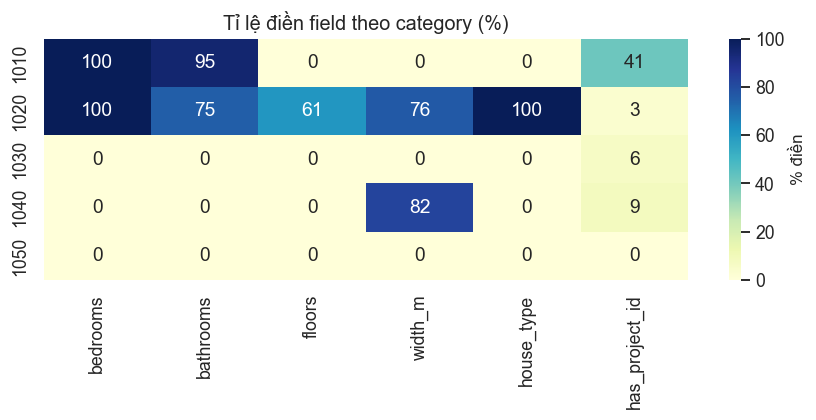

Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/fig_fill_rates_heatmap.png
house_type chỉ có ở 1020 — phân bố:


,count
house_type,
"Nhà ngõ, hẻm",1000517
"Nhà mặt phố, mặt tiền",407087
Nhà phố liền kề,72148
Nhà biệt thự,28098


✓ Assertions §4 passed


In [38]:
fields = ["bedrooms", "bathrooms", "floors", "width_m", "house_type", "has_project_id"]
fill_rows = []
for c in CAT_ORDER:
    sub = dim[dim.category == c]
    row = {"category": c, "ui_label": UI_LABELS[c], "n": len(sub)}
    for f in fields:
        col = sub["has_project_id"] if f == "has_project_id" else sub[f]
        row[f"pct_{f}"] = round(field_fill_rate(col), 2)
    fill_rows.append(row)
fill_df = pd.DataFrame(fill_rows)
display(fill_df)
fill_df.to_csv(OUT_DIR / "04_structural_fill_rates.csv", index=False)

heat = fill_df.set_index("category")[[c for c in fill_df.columns if c.startswith("pct_")]]
heat.columns = [c.replace("pct_", "") for c in heat.columns]
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% điền"})
ax.set_title("Tỉ lệ điền field theo category (%)")
ax.set_ylabel("")
show_and_save("fig_fill_rates_heatmap.png")

ht1020 = dim.loc[dim.category == 1020, "house_type"].dropna()
print("house_type chỉ có ở 1020 — phân bố:")
display(ht1020.value_counts().to_frame("count"))

assert fill_df.loc[fill_df.category == 1050, "pct_bedrooms"].iloc[0] < 5
assert fill_df.loc[fill_df.category == 1020, "pct_house_type"].iloc[0] > 99
assert fill_df.loc[fill_df.category == 1010, "pct_has_project_id"].iloc[0] > 30
assert fill_df.loc[fill_df.category == 1050, "pct_has_project_id"].iloc[0] < 1
print("✓ Assertions §4 passed")

## §5 — Chứng minh C: Đọc raw `title` (20 dòng/category)

In [39]:
samples = []
for c in CAT_ORDER:
    sub = dim[dim.category == c]
    s = sub.sample(min(20, len(sub)), random_state=c)
    s = s[["category", "ui_label", "readme_label", "ad_type", "price_bucket", "area_sqm", "title"]]
    samples.append(s)
sample_df = pd.concat(samples, ignore_index=True)
display(sample_df)
sample_df.to_csv(OUT_DIR / "05_title_samples_20_per_category.csv", index=False)

for c in CAT_ORDER:
    print(f"\n--- Category {c} ({UI_LABELS[c]}) — 3 title ngẫu nhiên ---")
    for t in dim.loc[dim.category == c, "title"].sample(3, random_state=c):
        print(f"  • {t[:120]}")

,category,ui_label,readme_label,ad_type,price_bucket,area_sqm,title
0,1010,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê,sell,5B–7B,120.0,TẬP THỂ TRƯƠNG ĐỊNH VIEW MẶT NGÕ CẦU THANG RIÊ...
1,1010,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê,let,7M–10M/tháng,37.0,CHDV STUDIO BAN CÔNG CÓ MÁY GIẶT RIÊNG GẦN TRỤ...
2,1010,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê,let,5M–7M/tháng,30.0,✨ CĂN HỘ 1PN TÁCH BẾP - FULL NỘI THẤT GẦN KHU ...
3,1010,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê,let,>30M/tháng,80.0,LUXURY APARTMENT_2BED_VINHOMES BASON
4,1010,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê,sell,3B–5B,98.0,"Bán căn 3PN-3WC 98m2 mặt tiền Ql13, 4ty7 có fi..."
...,...,...,...,...,...,...,...
95,1050,Phòng trọ,Dự án / căn hộ mở bán mới,let,2M–3M/tháng,20.0,Loại phòng ngủ
96,1050,Phòng trọ,Dự án / căn hộ mở bán mới,let,3M–5M/tháng,25.0,✅ CHỈNH CHỦ CHO THUÊPHÒNG TRỌ GIÁ RẺ MỚI XÂY ✅
97,1050,Phòng trọ,Dự án / căn hộ mở bán mới,let,20M–30M/tháng,150.0,cho thuê dãy nhà trọ 18 phòng
98,1050,Phòng trọ,Dự án / căn hộ mở bán mới,let,3M–5M/tháng,32.0,Phòng trọ bacol gần Aeon Tân Phú



--- Category 1010 (Căn hộ / Chung cư) — 3 title ngẫu nhiên ---
  • TẬP THỂ TRƯƠNG ĐỊNH VIEW MẶT NGÕ CẦU THANG RIÊNG BIỆT VÀO NHÀ Ở NGAY.
  • CHDV STUDIO BAN CÔNG CÓ MÁY GIẶT RIÊNG GẦN TRỤC ĐƯỜNG NGUYỄN VĂN TRỖI
  • ✨ CĂN HỘ 1PN TÁCH BẾP - FULL NỘI THẤT GẦN KHU PHAN XÍCH LONG ✨

--- Category 1020 (Nhà ở) — 3 title ngẫu nhiên ---
  • 🇻🇳 CHO THUÊ NHÀ 3 TẦNG: ĐƯỜNG MẸ THỨ - 3PN - 8tr - có sân ô tô
  • 🏡 NHÀ LÔ GÓC 2 MẶT HẺM – P. TÂN THUẬN ĐÔNG Q.7 - 70M2 - NHỈNH 5 TỶ
  • Cho thuê nhà hẻm xe hơi 6m Bàu Cát p14 Quận Tân Bình

--- Category 1030 (Văn phòng / Mặt bằng kinh doanh) — 3 title ngẫu nhiên ---
  • Cho thuê văn phòng Vạn Phúc City 55m², Ban công lớn, Giá chỉ 10 Triệu
  • Cho thuê nhà mặt tiền Tân Sơn Nhì,P.Tân Sơn Nhì, dt 5x20, 1 trệt 1 lầu
  • Cho thuê nhà mới GÓC 2MT NGUYỄN VĂN TRỖI Phú Nhuận Ngay khu ngân hàng

--- Category 1040 (Đất) — 3 title ngẫu nhiên ---
  • BÁN ĐẤT 590TR THỔ CƯ 7x32 – SỔ RIÊNG – GẦN KCN PHƯỚC ĐÔNG - ĐƯỜNGTHÔNG
  • Bán đất Đại Mỗ Ngõ thông ô tô
  • Bán Đất Lo

## §6 — Chứng minh D: NLP rules trên `title` & ma trận nhầm lẫn

,category,n,ui_label,pct_nlp_matches_ui
0,1010,611823,Căn hộ / Chung cư,57.995695
1,1020,1507864,Nhà ở,36.902864
2,1030,252402,Văn phòng / Mặt bằng kinh doanh,38.518712
3,1040,373469,Đất,46.032469
4,1050,361556,Phòng trọ,45.606766


nlp_category,can_ho,dat,mat_bang,nha_o,phong_tro,unknown
category,,,,,,
1010,58.0,0.0,0.2,0.5,10.9,30.4
1020,0.8,0.4,0.7,36.9,0.9,60.3
1030,1.1,0.1,38.5,10.6,1.0,48.7
1040,0.8,46.0,0.4,2.7,0.2,49.8
1050,11.3,0.0,0.2,1.0,45.6,41.9


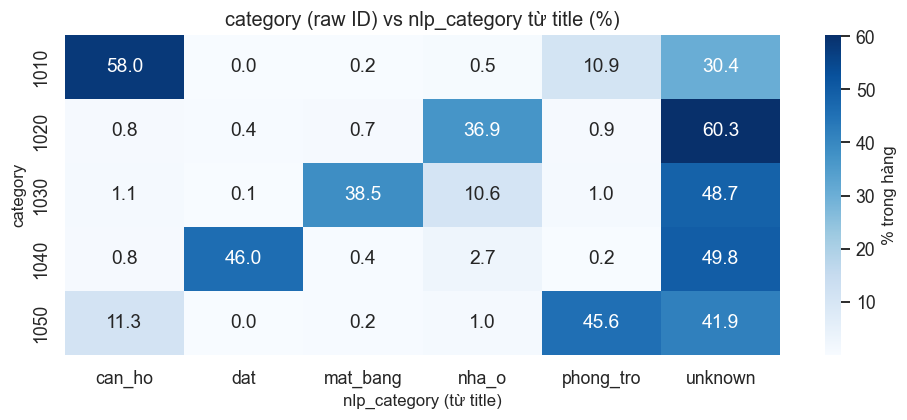

Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/fig_confusion_nlp.png
✓ Assertions §6 passed


In [40]:
RULES = [
    ("phong_tro", r"phòng trọ|phòng cho thuê|phong tro|studio|ktx|ký túc|gác xép|gác lửng|nhà trọ|phòng trống|pass phòng"),
    ("can_ho", r"căn hộ|can ho|chung cư|ccmn|duplex|penthouse|officetel|vinhomes|masteri"),
    ("nha_o", r"nhà nguyên căn|nhà cấp 4|nhà phố|biệt thự|nhà hẻm|bán nhà|nhà mặt tiền|nhà ngõ|dãy nhà"),
    ("dat", r"đất nền|đất thổ cư|lô đất|bán đất|đất ở|đất vườn|đất nông"),
    ("mat_bang", r"mặt bằng|văn phòng|kiot|kios|shophouse|sang quán|kho xưởng|nhà xưởng|mbkd"),
]

def nlp_from_title(title) -> str:
    if not isinstance(title, str) or not title.strip():
        return "unknown"
    t = title.lower()
    scores = [(name, len(re.findall(pat, t))) for name, pat in RULES]
    best = max(scores, key=lambda x: x[1])
    return best[0] if best[1] > 0 else "unknown"

dim["nlp_category"] = dim["title"].map(nlp_from_title)
dim["nlp_matches_ui"] = dim["nlp_category"] == dim["category_ui_slug"]

agree = dim.groupby("category").agg(
    n=("item_id", "count"),
    ui_label=("ui_label", "first"),
    pct_nlp_matches_ui=("nlp_matches_ui", lambda s: 100 * s.mean()),
).reset_index()
display(agree)
agree.to_csv(OUT_DIR / "06_nlp_agreement_by_category.csv", index=False)

conf = pd.crosstab(dim["category"], dim["nlp_category"], normalize="index") * 100
conf = conf.reindex(index=CAT_ORDER)
display(conf.round(1))
conf.round(1).to_csv(OUT_DIR / "07_confusion_category_vs_nlp_pct.csv")

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(conf, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% trong hàng"})
ax.set_title("category (raw ID) vs nlp_category từ title (%)")
ax.set_xlabel("nlp_category (từ title)")
show_and_save("fig_confusion_nlp.png")

assert agree.loc[agree.category == 1010, "pct_nlp_matches_ui"].iloc[0] > 50
assert agree.loc[agree.category == 1050, "pct_nlp_matches_ui"].iloc[0] > 40
assert agree.loc[agree.category == 1040, "pct_nlp_matches_ui"].iloc[0] > 40
print("✓ Assertions §6 passed")

## §7 — Chứng minh E: `ad_type` vs từ khóa trong `title` (bán/thuê lệch)

In [41]:
rent_kw = re.compile(r"cho thu[eê]|thuê |thuê|phòng trọ", re.I)
sell_kw = re.compile(r"\bbán\b|\bmở bán\b|\bcần bán\b", re.I)
ban_cong = re.compile(r"ban công|ban cong|bán công|luỹ bán|lũy bán|bán bích", re.I)

def title_has_real_sell(t) -> bool:
    if not isinstance(t, str):
        return False
    if not sell_kw.search(t):
        return False
    if ban_cong.search(t):
        return False
    return True

dim["title_rent_kw"] = dim["title"].apply(lambda t: bool(rent_kw.search(str(t))) if pd.notna(t) else False)
dim["title_sell_kw"] = dim["title"].apply(title_has_real_sell)

dim["mismatch_sell_with_rent_title"] = (dim.ad_type == "sell") & dim.title_rent_kw
dim["mismatch_let_with_sell_title"] = (dim.ad_type == "let") & dim.title_sell_kw

mm = dim.groupby("category").agg(
    n=("item_id", "count"),
    sell_plus_rent_title=("mismatch_sell_with_rent_title", "sum"),
    let_plus_sell_title=("mismatch_let_with_sell_title", "sum"),
).reset_index()
mm["pct_sell_rent_mismatch"] = (100 * mm["sell_plus_rent_title"] / mm["n"]).round(3)
mm["pct_let_sell_mismatch"] = (100 * mm["let_plus_sell_title"] / mm["n"]).round(3)
display(mm)
mm.to_csv(OUT_DIR / "08_adtype_title_mismatch.csv", index=False)

ex = dim[dim.mismatch_let_with_sell_title & (dim.category == 1050)][
    ["ad_type", "price_bucket", "title"]
].head(10)
print("Ví dụ 1050: ad_type=let nhưng title có 'bán' thật (không phải ban công):")
display(ex)

ex2 = dim[dim.mismatch_sell_with_rent_title & (dim.category == 1020)][
    ["ad_type", "price_bucket", "title"]
].head(10)
print("Ví dụ 1020: ad_type=sell nhưng title có từ thuê:")
display(ex2)

,category,n,sell_plus_rent_title,let_plus_sell_title,pct_sell_rent_mismatch,pct_let_sell_mismatch
0,1010,611823,2373,489,0.388,0.080
1,1020,1507864,17264,2871,1.145,0.190
2,1030,252402,924,2407,0.366,0.954
3,1040,373469,1464,125,0.392,0.033
4,1050,361556,1,567,0.000,0.157


Ví dụ 1050: ad_type=let nhưng title có 'bán' thật (không phải ban công):


,ad_type,price_bucket,title
70369,let,3M–5M/tháng,"Bằng bằng cho thuê,giá4tr500,có tolet,gác cao,..."
73753,let,>30M/tháng,Bán nhanh dãy trọ 300m2 full TC
73781,let,>30M/tháng,Bán dãy trọ 377m2 mặt tiền đường Bình Hòa 5 g...
74176,let,>30M/tháng,bán siêu phẩm CHDV Bình Tân
74521,let,5M–7M/tháng,Bán nhà gồm 8 phòng trọ đang cho thuê 800k/phò...
75230,let,3M–5M/tháng,Mặt tiền rộng buôn bán kinh doanh.mở văn phòng...
75309,let,7M–10M/tháng,cần bán nhà trọ chính chủ
76052,let,>30M/tháng,"Bán dãy trọ 300m2, thiết kế 1 trệt và 2 lầu, t..."
76472,let,>30M/tháng,bán bớt 1 căn phòng trọ
77698,let,3M–5M/tháng,cho thuê nhà gần chợ quảng việt (hoặc bán)


Ví dụ 1020: ad_type=sell nhưng title có từ thuê:


,ad_type,price_bucket,title
15400,sell,5B–7B,Nhà 2 tầng hẻm xe hơi Nguyên Hồng 3PN đang cho...
15670,sell,5B–7B,"Bán Nhà 50m2 5 tỷ Cầu Nguyễn Văn Cừ Quận 5, 2 ..."
15742,sell,7B–10B,Bán CHDV 8 phòng ngay trung tâm Quân8 cho thu...
15772,sell,3B–5B,ĐOÀN THỊ ĐIỂM- PHAN XÍCH LONG- PHÚ NHUẬN -23M2...
15877,sell,15B–20B,ngang 8m - CN117m2 5 tầng - 9PN cho thuê 60tr/th
15971,sell,3B–5B,GẤP ÂU CƠ P10 TÂN BÌNH - 4M X 11M - 2 TẦNG - C...
16059,sell,5B–7B,"CHỈ CẦN 2TY CÓ NHÀ 1T 3L, GẦN CHỢ HẠNH THÔNG T..."
16069,sell,10B–15B,🔥💯Bán nhà MTNB đường 12m Bình Phú 1 - 4x18m 4 ...
16072,sell,5B–7B,Nhà bán hoặc cho thuê
16083,sell,5B–7B,🔥 Bán nhà Âu Cơ - Tân Bình - 3 tầng - 48m2 - Đ...


## §8 — Chứng minh F: CVR (listing có ≥1 positive) — đặc biệt **1050 không có sell CVR**

Positive = README datathon: `view_phone`, `contact_chat`, …

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category,ad_type,listings,listings_with_positive,cvr_pct,ui_label,readme_label
0,1010,let,454716,85640,18.83,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê
1,1010,sell,157107,36134,23.00,Căn hộ / Chung cư,Phòng trọ / căn hộ cho thuê
2,1020,let,426019,87112,20.45,Nhà ở,Căn hộ / chung cư
3,1020,sell,1081845,209026,19.32,Nhà ở,Căn hộ / chung cư
4,1030,let,236484,48637,20.57,Văn phòng / Mặt bằng kinh doanh,Nhà ở
5,1030,sell,15918,3397,21.34,Văn phòng / Mặt bằng kinh doanh,Nhà ở
6,1040,let,7957,2058,25.86,Đất,Đất nền / BĐS thương mại
7,1040,sell,365512,77646,21.24,Đất,Đất nền / BĐS thương mại
8,1050,let,361553,80838,22.36,Phòng trọ,Dự án / căn hộ mở bán mới
9,1050,sell,3,0,0.00,Phòng trọ,Dự án / căn hộ mở bán mới


1050 sell: 3 tin, CVR = 0.0%
1050 let:  361,553 tin, CVR = 22.36%


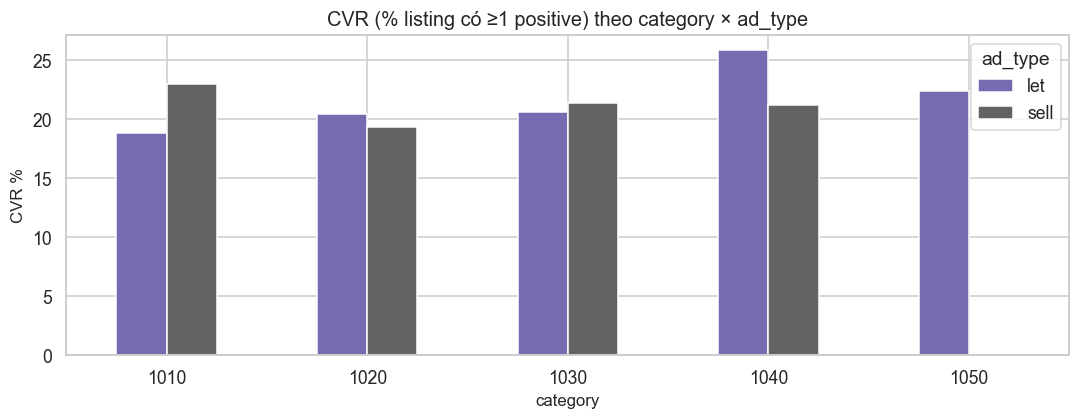

Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/fig_cvr_by_category_adtype.png
✓ Assertions §8 passed: 1050 sell không đóng góp CVR; let có CVR ~20%+


In [42]:
cvr = con.execute(f"""
WITH dim AS (
    SELECT item_id, category, ad_type
    FROM read_parquet('{DIM_GLOB}')
),
pos AS (
    SELECT DISTINCT item_id
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE event_type IN ({POS_SQL})
)
SELECT
    d.category,
    d.ad_type,
    COUNT(*) AS listings,
    COUNT(p.item_id) AS listings_with_positive,
    ROUND(100.0 * COUNT(p.item_id) / COUNT(*), 2) AS cvr_pct
FROM dim d
LEFT JOIN pos p ON d.item_id = p.item_id
GROUP BY 1, 2
ORDER BY 1, 2
""").df()

cvr["ui_label"] = cvr["category"].map(UI_LABELS)
cvr["readme_label"] = cvr["category"].map(README_LABELS)
display(cvr)
cvr.to_csv(OUT_DIR / "09_cvr_by_category_adtype.csv", index=False)

c1050_sell = cvr[(cvr.category == 1050) & (cvr.ad_type == "sell")]
c1050_let = cvr[(cvr.category == 1050) & (cvr.ad_type == "let")]
print(f"1050 sell: {c1050_sell.listings.iloc[0] if len(c1050_sell) else 0} tin, CVR = {c1050_sell.cvr_pct.iloc[0] if len(c1050_sell) else 'N/A'}%")
print(f"1050 let:  {c1050_let.listings.iloc[0]:,} tin, CVR = {c1050_let.cvr_pct.iloc[0]}%")

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = cvr.pivot(index="category", columns="ad_type", values="cvr_pct").reindex(CAT_ORDER)
plot_df.plot(kind="bar", ax=ax, rot=0, color=["#756bb1", "#636363"])
ax.set_title("CVR (% listing có ≥1 positive) theo category × ad_type")
ax.set_ylabel("CVR %")
ax.legend(title="ad_type")
show_and_save("fig_cvr_by_category_adtype.png")

sell_pos = int(c1050_sell["listings_with_positive"].iloc[0]) if len(c1050_sell) else 0
assert sell_pos == 0
assert c1050_let.cvr_pct.iloc[0] > 15
print("✓ Assertions §8 passed: 1050 sell không đóng góp CVR; let có CVR ~20%+")

## §9 — Chứng minh G: Data quality địa chỉ (popup UI: Tỉnh → Quận → Phường bắt buộc)

In [43]:
loc = dim.groupby("category").agg(
    n=("item_id", "count"),
    city_null=("city_name", lambda s: s.isna().sum()),
    district_null=("district_name", lambda s: s.isna().sum()),
    ward_null=("ward_name", lambda s: s.isna().sum()),
    loc_complete_pct=("loc_complete", lambda s: 100 * s.mean()),
).reset_index()
display(loc)
loc.to_csv(OUT_DIR / "10_location_completeness.csv", index=False)

schema_cols = set(dim.columns)
street_in_data = "street_name" in schema_cols or "address" in schema_cols
print(f"Cột tên đường / address trong dim_listing: {street_in_data}")
print("→ UI bắt buộc 'Tên đường' nhưng release chỉ có city/district/ward.")

assert loc["city_null"].sum() == 0
assert loc["ward_null"].sum() == 0
assert loc["district_null"].sum() < 10
print("✓ Assertions §9 passed: hierarchy gần như đầy đủ")

,category,n,city_null,district_null,ward_null,loc_complete_pct
0,1010,611823,0,0,0,100.000000
1,1020,1507864,0,0,0,100.000000
2,1030,252402,0,1,0,99.999604
3,1040,373469,0,2,0,99.999464
4,1050,361556,0,3,0,99.999170


Cột tên đường / address trong dim_listing: False
→ UI bắt buộc 'Tên đường' nhưng release chỉ có city/district/ward.
✓ Assertions §9 passed: hierarchy gần như đầy đủ


## §10 — Bảng số liệu tổng hợp (metrics, không assertion)

In [44]:
def pct(cond: pd.Series) -> float:
    return round(100 * cond.mean(), 4)


def add_metric(rows: list, section: str, metric: str, category, value, unit: str = "pct"):
    rows.append({
        "section": section,
        "metric": metric,
        "category": category,
        "value": value,
        "unit": unit,
    })


metric_rows: list[dict] = []
total_n = len(dim)
add_metric(metric_rows, "overview", "dim_listing_row_count", "all", total_n, "count")

for c in CAT_ORDER:
    sub = dim[dim.category == c]
    add_metric(metric_rows, "ad_type", "pct_let", c, pct(sub.ad_type.eq("let")))
    add_metric(metric_rows, "ad_type", "pct_sell", c, pct(sub.ad_type.eq("sell")))
    add_metric(metric_rows, "price", "pct_monthly_price_bucket", c, pct(sub.is_monthly_price))
    add_metric(metric_rows, "structure", "pct_project_id", c, pct(sub.has_project_id))
    add_metric(metric_rows, "structure", "pct_bedrooms_gt0", c, pct(sub.bedrooms.notna() & (sub.bedrooms > 0)))
    add_metric(metric_rows, "structure", "pct_floors_gt0", c, pct(sub.floors.notna() & (sub.floors > 0)))
    add_metric(metric_rows, "structure", "pct_width_m_gt0", c, pct(sub.width_m.notna() & (sub.width_m > 0)))
    add_metric(metric_rows, "structure", "pct_house_type_nonempty", c, pct(sub.house_type.notna() & sub.house_type.astype(str).str.strip().ne("")))
    add_metric(metric_rows, "location", "pct_loc_city_district_ward", c, pct(sub.loc_complete))
    for slug in ("phong_tro", "can_ho", "nha_o", "dat", "mat_bang", "unknown"):
        add_metric(metric_rows, "nlp_title", f"pct_title_{slug}", c, pct(sub.nlp_category == slug))
    add_metric(metric_rows, "nlp_title", "pct_title_matches_ui_slug", c, pct(sub.nlp_category == sub.category_ui_slug))

for _, r in cvr.iterrows():
    add_metric(
        metric_rows, "cvr",
        "listing_with_positive_pct",
        f"{int(r.category)}_{r.ad_type}",
        float(r.cvr_pct),
    )
    add_metric(metric_rows, "cvr", "listings", f"{int(r.category)}_{r.ad_type}", int(r.listings), "count")
    add_metric(metric_rows, "cvr", "listings_with_positive", f"{int(r.category)}_{r.ad_type}", int(r.listings_with_positive), "count")

metrics_long = pd.DataFrame(metric_rows)
display(metrics_long)
metrics_long.to_csv(OUT_DIR / "11_metrics_long.csv", index=False)
print(f"Saved → {OUT_DIR / '11_metrics_long.csv'}")

,section,metric,category,value,unit
0,overview,dim_listing_row_count,all,3.107114e+06,count
1,ad_type,pct_let,1010,7.432150e+01,pct
2,ad_type,pct_sell,1010,2.567850e+01,pct
3,price,pct_monthly_price_bucket,1010,7.432150e+01,pct
4,structure,pct_project_id,1010,4.139840e+01,pct
...,...,...,...,...,...
106,cvr,listings,1050_let,3.615530e+05,count
107,cvr,listings_with_positive,1050_let,8.083800e+04,count
108,cvr,listing_with_positive_pct,1050_sell,0.000000e+00,pct
109,cvr,listings,1050_sell,3.000000e+00,count


Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/11_metrics_long.csv


## §10b — Bảng 5 category: định nghĩa + chứng minh (đọc 1 lần là đủ)

Mỗi dòng trả lời: **(1)** loại BĐS đúng trên UI, **(2)** README đề bài nhầm gì, **(3)** số liệu + title mẫu chứng minh, **(4)** kết luận dùng label nào khi EDA.

In [45]:
# README gợi ý slug “sai” (để so với UI slug trên title)
README_MISLEAD_SLUG = {
    1010: "phong_tro",   # README: Phòng trọ / căn hộ cho thuê
    1020: "can_ho",      # README: Căn hộ / chung cư
    1030: "nha_o",       # README: Nhà ở
    1040: None,          # README gần đúng
    1050: "can_ho",      # README: Dự án / căn hộ mở bán mới
}

KET_LUAN = {
    1010: "1010 = Căn hộ/CC: form PN+tắm+dự án; title chủ yếu căn hộ — KHÔNG dùng nhãn Phòng trọ README.",
    1020: "1020 = Nhà ở (nguyên căn/phố/biệt thự): house_type 100%, bán ~72% — KHÔNG phải chung cư README.",
    1030: "1030 = MBKD/văn phòng: thuê ~94%, không PN; title mat_bang ~39% — KHÔNG phải Nhà ở README.",
    1040: "1040 = Đất: bán ~98%, width_m ~82%; title dat ~46% — cohort đất, README gần khớp.",
    1050: "1050 = Phòng trọ thuê: let 100%, 0% project_id, 3 tin sell/CVR=0 — KHÔNG phải dự án mới README.",
}


def pct_ad(cat: int, ad: str) -> float:
    row = adtype.loc[(adtype["category"] == cat) & (adtype["ad_type"] == ad), "pct_in_category"]
    return float(row.iloc[0]) if len(row) else 0.0


def chung_minh_hanh_vi(cat: int) -> str:
    let_v, sell_v = pct_ad(cat, "let"), pct_ad(cat, "sell")
    mon = float(monthly.loc[monthly["category"] == cat, "pct_monthly"].iloc[0])
    return f"let {let_v:.0f}% | sell {sell_v:.0f}% | giá/tháng {mon:.0f}%"


def chung_minh_title(cat: int) -> str:
    slug = UI_SLUG[cat]
    pct_ui = float(conf.loc[cat, slug]) if slug in conf.columns else 0.0
    mis = README_MISLEAD_SLUG.get(cat)
    if mis and mis in conf.columns:
        pct_readme = float(conf.loc[cat, mis])
        return f"title→{slug} {pct_ui:.0f}% (UI) >> {mis} {pct_readme:.1f}% (nhãn README)"
    return f"title→{slug} {pct_ui:.0f}% (UI slug)"


def chung_minh_form(cat: int) -> str:
    fr = fill_df.loc[fill_df["category"] == cat].iloc[0]
    if cat == 1010:
        return f"PN {fr['pct_bedrooms']:.0f}%, tắm {fr['pct_bathrooms']:.0f}%, project_id {fr['pct_has_project_id']:.0f}%"
    if cat == 1020:
        return f"house_type {fr['pct_house_type']:.0f}%, tầng {fr['pct_floors']:.0f}%, ngang {fr['pct_width_m']:.0f}%"
    if cat == 1030:
        return f"PN/tầm/ngang ~0% (form MBKD); project_id {fr['pct_has_project_id']:.1f}%"
    if cat == 1040:
        return f"PN 0%; chiều ngang {fr['pct_width_m']:.0f}% (đất)"
    if cat == 1050:
        sell_n = int(cvr.loc[(cvr["category"] == 1050) & (cvr["ad_type"] == "sell"), "listings"].iloc[0])
        sell_cvr = float(cvr.loc[(cvr["category"] == 1050) & (cvr["ad_type"] == "sell"), "cvr_pct"].iloc[0])
        return f"PN/tắm/dự án 0%; chỉ {sell_n} tin sell, CVR sell={sell_cvr:.0f}%"
    return ""


def readme_sai(cat: int) -> str:
    if cat == 1040:
        return "README gần đúng (Đất nền / BĐS TM)"
    return f"README: «{README_LABELS[cat]}»"


def title_mau(cat: int, n: int = 72) -> str:
    t = str(dim.loc[dim.category == cat, "title"].sample(1, random_state=cat).iloc[0])
    return (t[: n - 1] + "…") if len(t) > n else t


proof_rows = []
for c in CAT_ORDER:
    n_tin = int(dim.loc[dim.category == c].shape[0])
    proof_rows.append({
        "category": c,
        "n_tin": n_tin,
        "la_gi_dung": UI_LABELS[c],
        "readme_sai": readme_sai(c),
        "chung_minh_hanh_vi": chung_minh_hanh_vi(c),
        "chung_minh_title": chung_minh_title(c),
        "chung_minh_form": chung_minh_form(c),
        "title_mau": title_mau(c),
        "ket_luan": KET_LUAN[c],
    })

proof_compact = pd.DataFrame(proof_rows)
pd.set_option("display.max_colwidth", 140)
display(Markdown("### Bảng đầy đủ (export CSV)"))
display(proof_compact)
display(Markdown("### Tóm tắt — đọc 5 dòng này trước"))
display(proof_compact[["category", "la_gi_dung", "readme_sai", "ket_luan"]])
proof_compact.to_csv(OUT_DIR / "00_category_proof_5rows.csv", index=False)
print(f"Saved → {OUT_DIR / '00_category_proof_5rows.csv'}")
display(
    Markdown(
        "**Quy tắc EDA:** luôn `category` → `ui_label` (cột `la_gi_dung`). "
        "Cột `readme_sai` chỉ để thấy lệch Data Dictionary — không dùng làm nhãn cohort."
    )
)

### Bảng đầy đủ (export CSV)

,category,n_tin,la_gi_dung,readme_sai,chung_minh_hanh_vi,chung_minh_title,chung_minh_form,title_mau,ket_luan
0,1010,611823,Căn hộ / Chung cư,README: «Phòng trọ / căn hộ cho thuê»,let 74% | sell 26% | giá/tháng 74%,title→can_ho 58% (UI) >> phong_tro 10.9% (nhãn README),"PN 100%, tắm 95%, project_id 41%",TẬP THỂ TRƯƠNG ĐỊNH VIEW MẶT NGÕ CẦU THANG RIÊNG BIỆT VÀO NHÀ Ở NGAY.,1010 = Căn hộ/CC: form PN+tắm+dự án; title chủ yếu căn hộ — KHÔNG dùng nhãn Phòng trọ README.
1,1020,1507864,Nhà ở,README: «Căn hộ / chung cư»,let 28% | sell 72% | giá/tháng 28%,title→nha_o 37% (UI) >> can_ho 0.8% (nhãn README),"house_type 100%, tầng 61%, ngang 76%",🇻🇳 CHO THUÊ NHÀ 3 TẦNG: ĐƯỜNG MẸ THỨ - 3PN - 8tr - có sân ô tô,"1020 = Nhà ở (nguyên căn/phố/biệt thự): house_type 100%, bán ~72% — KHÔNG phải chung cư README."
2,1030,252402,Văn phòng / Mặt bằng kinh doanh,README: «Nhà ở»,let 94% | sell 6% | giá/tháng 94%,title→mat_bang 39% (UI) >> nha_o 10.6% (nhãn README),PN/tầm/ngang ~0% (form MBKD); project_id 6.5%,"Cho thuê văn phòng Vạn Phúc City 55m², Ban công lớn, Giá chỉ 10 Triệu","1030 = MBKD/văn phòng: thuê ~94%, không PN; title mat_bang ~39% — KHÔNG phải Nhà ở README."
3,1040,373469,Đất,README gần đúng (Đất nền / BĐS TM),let 2% | sell 98% | giá/tháng 2%,title→dat 46% (UI slug),PN 0%; chiều ngang 82% (đất),BÁN ĐẤT 590TR THỔ CƯ 7x32 – SỔ RIÊNG – GẦN KCN PHƯỚC ĐÔNG - ĐƯỜNGTHÔNG,"1040 = Đất: bán ~98%, width_m ~82%; title dat ~46% — cohort đất, README gần khớp."
4,1050,361556,Phòng trọ,README: «Dự án / căn hộ mở bán mới»,let 100% | sell 0% | giá/tháng 100%,title→phong_tro 46% (UI) >> can_ho 11.3% (nhãn README),"PN/tắm/dự án 0%; chỉ 3 tin sell, CVR sell=0%",Cho thuê phòng trọ có gác lửng giá rẻ,"1050 = Phòng trọ thuê: let 100%, 0% project_id, 3 tin sell/CVR=0 — KHÔNG phải dự án mới README."


### Tóm tắt — đọc 5 dòng này trước

,category,la_gi_dung,readme_sai,ket_luan
0,1010,Căn hộ / Chung cư,README: «Phòng trọ / căn hộ cho thuê»,1010 = Căn hộ/CC: form PN+tắm+dự án; title chủ yếu căn hộ — KHÔNG dùng nhãn Phòng trọ README.
1,1020,Nhà ở,README: «Căn hộ / chung cư»,"1020 = Nhà ở (nguyên căn/phố/biệt thự): house_type 100%, bán ~72% — KHÔNG phải chung cư README."
2,1030,Văn phòng / Mặt bằng kinh doanh,README: «Nhà ở»,"1030 = MBKD/văn phòng: thuê ~94%, không PN; title mat_bang ~39% — KHÔNG phải Nhà ở README."
3,1040,Đất,README gần đúng (Đất nền / BĐS TM),"1040 = Đất: bán ~98%, width_m ~82%; title dat ~46% — cohort đất, README gần khớp."
4,1050,Phòng trọ,README: «Dự án / căn hộ mở bán mới»,"1050 = Phòng trọ thuê: let 100%, 0% project_id, 3 tin sell/CVR=0 — KHÔNG phải dự án mới README."


Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/00_category_proof_5rows.csv


**Quy tắc EDA:** luôn `category` → `ui_label` (cột `la_gi_dung`). Cột `readme_sai` chỉ để thấy lệch Data Dictionary — không dùng làm nhãn cohort.

## §12 — Bằng chứng bổ sung (SQL trên Parquet: diện tích, phòng ngủ, pháp lý, snapshot, post_contact)

In [46]:
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")
PCI_GLOB = str(DATA_ROOT / "fact_post_contact_interactions" / "*.parquet")

area_q = con.execute(f"""
SELECT category, COUNT(*) AS n_rows,
  ROUND(quantile_cont(area_sqm, 0.25), 1) AS p25_m2,
  ROUND(quantile_cont(area_sqm, 0.5), 1) AS p50_m2,
  ROUND(quantile_cont(area_sqm, 0.75), 1) AS p75_m2,
  ROUND(AVG(area_sqm), 1) AS mean_m2
FROM read_parquet('{DIM_GLOB}')
WHERE area_sqm IS NOT NULL AND area_sqm > 0
GROUP BY 1 ORDER BY 1
""").df()
area_q.to_csv(OUT_DIR / "12a_area_percentiles_m2.csv", index=False)
display(area_q)

bands = con.execute(f"""
SELECT category,
  ROUND(100.0 * SUM(CASE WHEN area_sqm > 0 AND area_sqm <= 35 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_m2_le_35,
  ROUND(100.0 * SUM(CASE WHEN area_sqm > 35 AND area_sqm <= 80 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_m2_35_80,
  ROUND(100.0 * SUM(CASE WHEN area_sqm > 80 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_m2_gt_80
FROM read_parquet('{DIM_GLOB}')
GROUP BY 1 ORDER BY 1
""").df()
bands.to_csv(OUT_DIR / "12b_area_band_pct.csv", index=False)
display(bands)

bed_sql = con.execute(f"""
SELECT category,
  ROUND(100.0 * SUM(CASE WHEN bedrooms IS NULL OR bedrooms = 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_no_bedroom,
  ROUND(quantile_cont(NULLIF(bedrooms, 0), 0.5), 1) AS median_bedrooms_when_gt0
FROM read_parquet('{DIM_GLOB}')
GROUP BY 1 ORDER BY 1
""").df()
bed_sql.to_csv(OUT_DIR / "12c_bedroom_summary.csv", index=False)
display(bed_sql)

legal_dir = con.execute(f"""
SELECT category,
  ROUND(100.0 * SUM(CASE WHEN legal_status IS NOT NULL AND TRIM(legal_status) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_legal_filled,
  ROUND(100.0 * SUM(CASE WHEN direction IS NOT NULL AND TRIM(direction) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_direction_filled
FROM read_parquet('{DIM_GLOB}')
GROUP BY 1 ORDER BY 1
""").df()
legal_dir.to_csv(OUT_DIR / "12d_legal_direction_fill_pct.csv", index=False)
display(legal_dir)

fur_img = con.execute(f"""
SELECT category,
  ROUND(100.0 * SUM(CASE WHEN furnishing IS NOT NULL AND TRIM(furnishing) != '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_furnishing_filled,
  ROUND(quantile_cont(images_count, 0.5), 1) AS median_images_count
FROM read_parquet('{DIM_GLOB}')
GROUP BY 1 ORDER BY 1
""").df()
fur_img.to_csv(OUT_DIR / "12e_furnishing_images.csv", index=False)
display(fur_img)

snap = con.execute(f"""
SELECT d.category,
  COUNT(DISTINCT s.item_id) AS items_in_snapshot,
  ROUND(AVG(s.views_24h), 2) AS avg_views_24h,
  ROUND(AVG(s.contacts_24h), 4) AS avg_contacts_24h
FROM read_parquet('{SNAP_GLOB}') s
JOIN read_parquet('{DIM_GLOB}') d ON s.item_id = d.item_id
GROUP BY 1 ORDER BY 1
""").df()
snap.to_csv(OUT_DIR / "12f_listing_snapshot_by_category.csv", index=False)
display(snap)

pci = con.execute(f"""
SELECT category, COUNT(*) AS interaction_rows
FROM read_parquet('{PCI_GLOB}')
GROUP BY 1 ORDER BY 1
""").df()
pci.to_csv(OUT_DIR / "12g_post_contact_rows_by_category.csv", index=False)
display(pci)

print("Saved §12 CSV →", OUT_DIR)

,category,n_rows,p25_m2,p50_m2,p75_m2,mean_m2
0,1010,611793,35.0,50.0,70.0,77.8
1,1020,1507850,41.0,60.0,86.0,86.4
2,1030,252401,70.0,140.0,350.0,657.2
3,1040,373467,90.0,125.0,267.0,893.0
4,1050,361544,20.0,25.0,30.0,91.5


,category,pct_m2_le_35,pct_m2_35_80,pct_m2_gt_80
0,1010,29.55,56.57,13.87
1,1020,16.61,55.65,27.74
2,1030,8.73,22.40,68.87
3,1040,0.69,19.52,79.79
4,1050,89.64,9.64,0.71


,category,pct_no_bedroom,median_bedrooms_when_gt0
0,1010,0.0,1.0
1,1020,0.0,3.0
2,1030,100.0,NaN
3,1040,100.0,NaN
4,1050,100.0,NaN


,category,pct_legal_filled,pct_direction_filled
0,1010,97.04,12.04
1,1020,97.94,20.68
2,1030,95.35,14.48
3,1040,98.42,35.52
4,1050,0.00,0.00


,category,pct_furnishing_filled,median_images_count
0,1010,59.02,7.0
1,1020,46.92,6.0
2,1030,29.88,4.0
3,1040,0.00,4.0
4,1050,71.92,6.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category,items_in_snapshot,avg_views_24h,avg_contacts_24h
0,1010,132702,5.18,2.2604
1,1020,328233,5.88,2.6956
2,1030,56918,5.03,2.4302
3,1040,86262,3.77,2.1827
4,1050,88548,11.88,2.8188


,category,interaction_rows
0,1010,4022460
1,1020,10617046
2,1030,1572178
3,1040,2280176
4,1050,6994585


Saved §12 CSV → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping


## §13 — Quy tắc EDA theo `category` (luồng thuộc tính `dim_listing`)

Dùng **`category` theo UI đã chứng minh** (1010=Căn hộ, 1020=Nhà ở, 1030=Mặt bằng, 1040=Đất, 1050=Phòng trọ), **không** theo nhãn README.

### Ý nghĩa `eda_role`

| Role | Cách dùng trong EDA |
|------|---------------------|
| **primary** | Feature / stratify / cohort chính; vẫn kiểm tra missing |
| **secondary** | Bổ sung mô tả, cohort phụ |
| **optional** | Có ý nghĩa khi đủ dữ liệu; tránh so sánh xuyên category |
| **caution** | Dùng được nhưng bias missing / nhầm lẫn README — cần flag |
| **ignore** | Không có trên form UI tương ứng hoặc ~0% điền — **không** dùng làm feature so sánh |

### Luồng tóm tắt theo phân khúc (UI)

- **1010 — Căn hộ:** `ad_type`, `price_bucket`, `area_sqm`, `bedrooms`/`bathrooms`, `project_id`, `furnishing`, địa chỉ, `title`. Không dùng `floors`/`width_m`/`house_type` cho cohort chuẩn.
- **1020 — Nhà ở:** `house_type`, `floors`, `width_m`, `bedrooms`, `ad_type`, `price_bucket`, `legal_status`, `area_sqm`, địa chỉ. `project_id` thưa — chỉ optional/caution.
- **1030 — Mặt bằng:** `ad_type` (let nặng), `price_bucket`, `area_sqm`, `title`, địa chỉ. Bỏ `bedrooms`/`floors`/`width_m`/`house_type`.
- **1040 — Đất:** `ad_type` (sell), `width_m`, `area_sqm`, `direction`, `legal_status`, `price_bucket`, địa chỉ. Bỏ nội thất / PN / tầng.
- **1050 — Phòng trọ:** `ad_type` (let), `price_bucket` (tháng), `area_sqm` (nhỏ), `furnishing`, `title`, địa chỉ. **Không** `project_id`, `legal_status`, `direction`, `house_type`.

Cell dưới xuất bảng dài + ma trận + hàm `dim_listing_eda_role()` để tái sử dụng.

In [47]:
# --- Quy tắc EDA dim_listing theo category (UI) ---
# eda_role: primary | secondary | optional | caution | ignore

DIM_ATTR_FLOW: dict[int, dict[str, tuple[str, str]]] = {
    1010: {
        "ad_type": ("primary", "Bán vs thuê — stratify CVR/giá"),
        "price_bucket": ("primary", "Bucket giá theo loại giao dịch"),
        "title": ("primary", "NLP / embedding; cross-check ad_type"),
        "area_sqm": ("primary", "Diện tích căn"),
        "bedrooms": ("primary", "Form căn hộ bắt PN"),
        "bathrooms": ("secondary", "Điền cao"),
        "furnishing": ("secondary", "Nội thất"),
        "project_id": ("caution", "~41% có — thêm flag has_project"),
        "images_count": ("secondary", "Số ảnh"),
        "city_name": ("primary", "Địa lý"),
        "district_name": ("primary", ""),
        "ward_name": ("primary", ""),
        "seller_type": ("secondary", "agent vs private"),
        "ad_status": ("secondary", "deleted/accepted/hidden"),
        "posted_date": ("secondary", "Thời gian"),
        "expected_expired_date": ("optional", ""),
        "seller_id": ("optional", "Chủ tin — join"),
        "direction": ("optional", "Tỉ lệ điền thấp"),
        "legal_status": ("caution", "Có ý nghĩa bán; kiểm missing"),
        "floors": ("ignore", "~0% điền — không form căn hộ"),
        "width_m": ("ignore", "~0% điền"),
        "house_type": ("ignore", "Chỉ meaningful ở 1020"),
    },
    1020: {
        "ad_type": ("primary", ""),
        "price_bucket": ("primary", ""),
        "title": ("primary", ""),
        "house_type": ("primary", "Nhà ngõ / mặt phố / liền kề / biệt thự"),
        "floors": ("primary", "~61% điền"),
        "width_m": ("primary", "Mặt tiền ~76%"),
        "area_sqm": ("primary", ""),
        "bedrooms": ("primary", ""),
        "bathrooms": ("secondary", ""),
        "legal_status": ("secondary", ""),
        "direction": ("optional", ""),
        "furnishing": ("secondary", ""),
        "project_id": ("caution", "~3% — flag has_project"),
        "city_name": ("primary", ""),
        "district_name": ("primary", ""),
        "ward_name": ("primary", ""),
        "seller_type": ("secondary", ""),
        "ad_status": ("secondary", ""),
        "images_count": ("secondary", ""),
        "posted_date": ("secondary", ""),
        "expected_expired_date": ("optional", ""),
        "seller_id": ("optional", ""),
    },
    1030: {
        "ad_type": ("primary", "Let ~94%"),
        "price_bucket": ("primary", "Chủ yếu /tháng"),
        "title": ("primary", "MBKD / kho / sang quán"),
        "area_sqm": ("primary", "Median lớn — MB/kho"),
        "city_name": ("primary", ""),
        "district_name": ("primary", ""),
        "ward_name": ("primary", ""),
        "furnishing": ("optional", "Tỉ lệ điền thấp hơn 1010/1050"),
        "images_count": ("secondary", ""),
        "seller_type": ("secondary", ""),
        "ad_status": ("secondary", ""),
        "posted_date": ("secondary", ""),
        "legal_status": ("secondary", ""),
        "direction": ("optional", ""),
        "bedrooms": ("ignore", "100% không PN theo form"),
        "bathrooms": ("ignore", ""),
        "floors": ("ignore", ""),
        "width_m": ("ignore", ""),
        "house_type": ("ignore", ""),
        "project_id": ("caution", "~6.5% — không phải trục chính"),
        "expected_expired_date": ("optional", ""),
        "seller_id": ("optional", ""),
    },
    1040: {
        "ad_type": ("primary", "Sell ~98%"),
        "price_bucket": ("primary", ""),
        "title": ("primary", "đất / lô / thổ"),
        "area_sqm": ("primary", "Diện tích đất"),
        "width_m": ("primary", "Chiều ngang ~82%"),
        "direction": ("secondary", "Hướng đất ~36%"),
        "legal_status": ("primary", ""),
        "city_name": ("primary", ""),
        "district_name": ("primary", ""),
        "ward_name": ("primary", ""),
        "images_count": ("secondary", ""),
        "seller_type": ("secondary", ""),
        "ad_status": ("secondary", ""),
        "posted_date": ("secondary", ""),
        "bedrooms": ("ignore", ""),
        "bathrooms": ("ignore", ""),
        "floors": ("ignore", ""),
        "house_type": ("ignore", ""),
        "furnishing": ("ignore", "0% điền"),
        "project_id": ("caution", "~8.6%"),
        "expected_expired_date": ("optional", ""),
        "seller_id": ("optional", ""),
    },
    1050: {
        "ad_type": ("primary", "Let ~100%"),
        "price_bucket": ("primary", "100% /tháng"),
        "title": ("primary", "phòng trọ / studio"),
        "area_sqm": ("primary", "Median ~25m2; ~90% ≤35m2"),
        "furnishing": ("primary", "Form phòng trọ"),
        "city_name": ("primary", ""),
        "district_name": ("primary", ""),
        "ward_name": ("primary", ""),
        "images_count": ("secondary", ""),
        "seller_type": ("secondary", ""),
        "ad_status": ("secondary", ""),
        "posted_date": ("secondary", ""),
        "bedrooms": ("ignore", ""),
        "bathrooms": ("ignore", ""),
        "floors": ("ignore", ""),
        "width_m": ("ignore", ""),
        "house_type": ("ignore", ""),
        "project_id": ("ignore", "0%"),
        "legal_status": ("ignore", "0% điền"),
        "direction": ("ignore", "0% điền"),
        "expected_expired_date": ("optional", ""),
        "seller_id": ("optional", ""),
    },
}

for _c in DIM_ATTR_FLOW:
    _d = {"item_id": ("primary", "Khóa join fact / events")}
    _d.update(DIM_ATTR_FLOW[_c])
    DIM_ATTR_FLOW[_c] = _d


def dim_listing_eda_role(category: int, attribute: str) -> str:
    """Trả về eda_role cho (category, attribute). Unknown attribute -> 'optional'."""
    spec = DIM_ATTR_FLOW.get(int(category), {})
    if attribute in spec:
        return spec[attribute][0]
    return "optional"


def dim_listing_eda_note(category: int, attribute: str) -> str:
    spec = DIM_ATTR_FLOW.get(int(category), {})
    return spec.get(attribute, ("optional", ""))[1]


rows_long = []
for cat, attrs in DIM_ATTR_FLOW.items():
    for attr, (role, note) in attrs.items():
        rows_long.append({
            "category": cat,
            "ui_label": UI_LABELS[cat],
            "attribute": attr,
            "eda_role": role,
            "note": note,
        })
rules_long = pd.DataFrame(rows_long).sort_values(["category", "eda_role", "attribute"])
rules_long.to_csv(OUT_DIR / "13_dim_listing_eda_rules_long.csv", index=False)
display(rules_long)
print(f"Saved → {OUT_DIR / '13_dim_listing_eda_rules_long.csv'}")

# Ma trận: attribute × category → role (pivot)
pivot = rules_long.pivot(index="attribute", columns="category", values="eda_role").reindex(
    sorted(rules_long["attribute"].unique()),
    axis=0,
)
pivot.columns = [f"cat_{c}" for c in pivot.columns]
pivot.to_csv(OUT_DIR / "13b_dim_listing_eda_role_matrix.csv")
display(pivot)
print(f"Saved → {OUT_DIR / '13b_dim_listing_eda_role_matrix.csv'}")

# Gợi ý filter pipeline EDA
EDA_PIPELINE = [
    ("Bước 0", "Luôn map category → ui_label; không dùng readme_label cho cohort."),
    ("Bước 1", "Stratify theo ad_type + price_bucket trước khi so area_sqm / CVR."),
    ("Bước 2", "Chỉ join/feature các cột có eda_role != ignore trong từng category."),
    ("Bước 3", "Cột caution: thêm has_* hoặc impute riêng; không đổ missing thành global mean xuyên category."),
    ("Bước 4", "Cross-category chart: dùng ui_label + ad_type; tránh house_type/floors nếu mix 1010+1020."),
]
pipe_df = pd.DataFrame(EDA_PIPELINE, columns=["step", "rule"])
pipe_df.to_csv(OUT_DIR / "13c_eda_pipeline_hints.csv", index=False)
display(pipe_df)
print(f"Saved → {OUT_DIR / '13c_eda_pipeline_hints.csv'}")

,category,ui_label,attribute,eda_role,note
19,1010,Căn hộ / Chung cư,legal_status,caution,Có ý nghĩa bán; kiểm missing
8,1010,Căn hộ / Chung cư,project_id,caution,~41% có — thêm flag has_project
20,1010,Căn hộ / Chung cư,floors,ignore,~0% điền — không form căn hộ
22,1010,Căn hộ / Chung cư,house_type,ignore,Chỉ meaningful ở 1020
21,1010,Căn hộ / Chung cư,width_m,ignore,~0% điền
...,...,...,...,...,...
100,1050,Phòng trọ,ward_name,primary,
103,1050,Phòng trọ,ad_status,secondary,
101,1050,Phòng trọ,images_count,secondary,
104,1050,Phòng trọ,posted_date,secondary,


Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/13_dim_listing_eda_rules_long.csv


,cat_1010,cat_1020,cat_1030,cat_1040,cat_1050
attribute,,,,,
ad_status,secondary,secondary,secondary,secondary,secondary
ad_type,primary,primary,primary,primary,primary
area_sqm,primary,primary,primary,primary,primary
bathrooms,secondary,secondary,ignore,ignore,ignore
bedrooms,primary,primary,ignore,ignore,ignore
city_name,primary,primary,primary,primary,primary
direction,optional,optional,optional,secondary,ignore
district_name,primary,primary,primary,primary,primary
expected_expired_date,optional,optional,optional,optional,optional


Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/13b_dim_listing_eda_role_matrix.csv


,step,rule
0,Bước 0,Luôn map category → ui_label; không dùng readme_label cho cohort.
1,Bước 1,Stratify theo ad_type + price_bucket trước khi so area_sqm / CVR.
2,Bước 2,Chỉ join/feature các cột có eda_role != ignore trong từng category.
3,Bước 3,Cột caution: thêm has_* hoặc impute riêng; không đổ missing thành global mean xuyên category.
4,Bước 4,Cross-category chart: dùng ui_label + ad_type; tránh house_type/floors nếu mix 1010+1020.


Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/13c_eda_pipeline_hints.csv


## §11 — Gộp toàn bộ CSV → file đọc (chỉ số liệu)

In [48]:
SUMMARY_PATH = OUT_DIR / "category_mapping_data_summary.md"

TABLE_FILES_MAIN = [
    ("00_proof_compact", "00_category_proof_5rows.csv", None),
    ("01_mapping", "01_readme_vs_ui_mapping.csv", ["category", "readme_label", "ui_label_corrected", "nlp_slug"]),
    ("02_ad_type", "02_ad_type_by_category.csv", None),
    ("03_monthly_price", "03_monthly_price_share.csv", None),
    ("04_structural_fill", "04_structural_fill_rates.csv", None),
    ("06_nlp_agreement", "06_nlp_agreement_by_category.csv", None),
    ("07_nlp_confusion_pct", "07_confusion_category_vs_nlp_pct.csv", None),
    ("08_adtype_title_mismatch", "08_adtype_title_mismatch.csv", None),
    ("09_cvr", "09_cvr_by_category_adtype.csv", ["category", "ad_type", "listings", "listings_with_positive", "cvr_pct"]),
    ("10_location", "10_location_completeness.csv", None),
    ("11_metrics_long", "11_metrics_long.csv", None),
]
TABLE_FILES_EXTRA = [
    ("12a_area_percentiles", "12a_area_percentiles_m2.csv", None),
    ("12b_area_bands", "12b_area_band_pct.csv", None),
    ("12c_bedroom", "12c_bedroom_summary.csv", None),
    ("12d_legal_direction", "12d_legal_direction_fill_pct.csv", None),
    ("12e_furnishing_images", "12e_furnishing_images.csv", None),
    ("12f_snapshot", "12f_listing_snapshot_by_category.csv", None),
    ("12g_post_contact", "12g_post_contact_rows_by_category.csv", None),
    ("13_eda_rules_long", "13_dim_listing_eda_rules_long.csv", None),
    ("13b_eda_role_matrix", "13b_dim_listing_eda_role_matrix.csv", None),
    ("13c_eda_pipeline", "13c_eda_pipeline_hints.csv", None),
]


def df_to_md_table(df: pd.DataFrame) -> str:
    cols = [str(c) for c in df.columns]
    lines = ["| " + " | ".join(cols) + " |", "| " + " | ".join(["---"] * len(cols)) + " |"]
    for _, row in df.iterrows():
        cells = []
        for cname, v in zip(df.columns, row):
            if isinstance(v, float):
                cells.append(f"{v:.4g}" if abs(v) < 1e6 else f"{v:,.0f}")
            elif isinstance(v, (int, np.integer)):
                if str(cname) == "category" and 1000 <= int(v) <= 2000:
                    cells.append(str(int(v)))
                else:
                    cells.append(f"{int(v):,}")
            else:
                cells.append(str(v).replace("|", "\\|"))
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


parts = [
    "# Category mapping — số liệu tổng hợp",
    "",
    f"- dim_listing: {len(dim):,} dòng",
    f"- Sinh từ: `eda_category_mapping_proof.ipynb`",
    "",
]

for section_id, fname, keep_cols in TABLE_FILES_MAIN:
    path = OUT_DIR / fname
    if not path.exists():
        parts.append(f"## {section_id}\n\n(file missing: {fname})\n")
        continue
    tdf = pd.read_csv(path)
    if keep_cols:
        tdf = tdf[[c for c in keep_cols if c in tdf.columns]]
    parts.append(f"## {section_id}\n")
    parts.append(df_to_md_table(tdf))
    parts.append("")

parts.append("## §12 — Bổ sung (diện tích, pháp lý, snapshot, post_contact)\n")
parts.append("")

for section_id, fname, keep_cols in TABLE_FILES_EXTRA:
    path = OUT_DIR / fname
    if not path.exists():
        parts.append(f"## {section_id}\n\n(file missing: {fname})\n")
        continue
    tdf = pd.read_csv(path)
    if keep_cols:
        tdf = tdf[[c for c in keep_cols if c in tdf.columns]]
    parts.append(f"## {section_id}\n")
    parts.append(df_to_md_table(tdf))
    parts.append("")

SUMMARY_PATH.write_text("\n".join(parts), encoding="utf-8")
print(f"Saved → {SUMMARY_PATH}")
print(f"({SUMMARY_PATH.stat().st_size // 1024} KB)")

Saved → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/category_mapping/category_mapping_data_summary.md
(23 KB)
